In [1]:
import sys
import importlib

import numpy as np
import pandas as pd
import os.path

# Import the model we are using
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
import sys
sys.path.append('.') # Adds the current directory
import BTSSlayers as btss 

In [3]:
# Read a large set of 491 translation sessions from the TPR-DB
GD = pd.read_csv('sorted.gaze.clean.txt', sep="\t", dtype=None)

# read the Tables from the TPR-DB
BTSS1 = btss.readBTSSsessions(GD['Study-Session'], layers = ['au1', 'fd','kd'], verbose=0)

# rename for easier use
AUdf_old = BTSS1['au1']
FDdf = BTSS1['fd'] 
KDdf_old = BTSS1['kd']
print("AUs:", AUdf_old.shape, "FDs:", FDdf.shape, "KDs:", KDdf_old.shape)

AUs: (263719, 73) FDs: (999492, 22) KDs: (564649, 25)


In [5]:
KDdf_old['StudySession'] = KDdf_old['Study'] + '-' + KDdf_old['Session']
KDdf_old.shape

(564649, 26)

Plotting IKI distribution for Session: ACS08-P01_T3
Total IKI values in this session: 1546


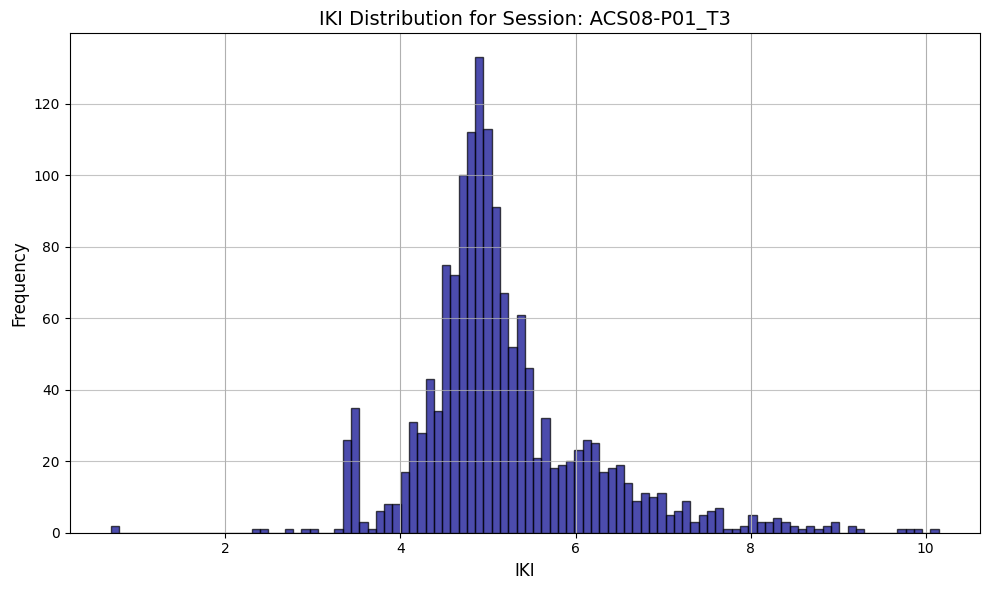

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


KDdf = KDdf_old.copy() 

# Ensure the DataFrame is sorted correctly for the IKI calculation
KDdf = KDdf.sort_values(by=['StudySession', 'Time'])

# Calculate IKI grouped by StudySession. The .diff() resets for each session.
KDdf['IKI'] = KDdf.groupby('StudySession')['Time'].diff()

# Remove the NaN values created at the start of each session
KDdf_iki = KDdf.dropna(subset=['IKI']).copy()

KDdf_iki['LogIKI'] = np.log(KDdf_iki.IKI)
session_id_to_plot = KDdf_iki['StudySession'].unique()[0] 

session_data = KDdf_iki[KDdf_iki['StudySession'] == session_id_to_plot]

print(f"Plotting IKI distribution for Session: {session_id_to_plot}")
print(f"Total IKI values in this session: {len(session_data)}")

plt.figure(figsize=(10, 6))

# Plot the histogram of the IKI values
session_data['LogIKI'][session_data.IKI > 1].hist(bins=100, edgecolor='black', color='darkblue', alpha=0.7) 

# Set plot title and labels
plt.title(f'IKI Distribution for Session: {session_id_to_plot}', fontsize=14)
plt.xlabel('IKI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [11]:
AUdf_old['StudySession'] = AUdf_old['Study'] + '-' + AUdf_old['Session']
AUdf_old = AUdf_old.drop_duplicates(subset=['StudySession'])
x = AUdf_old[AUdf_old['StudySession']=='ACS08-P01_T3'][['PUB','KBI']]
x

,PUB,KBI
6421,567,274


In [12]:
x['PUB1'] = x['PUB']/3
x['KBI1'] = x['KBI']/2
x['LogPUB'] = np.log(x.PUB1)
x['LogKBI'] = np.log(x.KBI1)
x

,PUB,KBI,PUB1,KBI1,LogPUB,LogKBI
6421,567,274,189.0,137.0,5.241747,4.919981


In [13]:
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq
import pandas as pd # You'll need pandas for the input data

def get_gmm_thresholds_logiki(log_iki_data, n_components=2, random_state=42):
    """
    Fit Gaussian Mixture Models (GMM) to LogIKI data and calculate 
    threshold at the intersection of the first two distributions.

    Parameters:
        log_iki_data : pd.Series or np.ndarray. Log-transformed IKI data to fit GMM.
        n_components : int, optional, Number of mixture components (default=2).
        random_state : int, optional, Random seed for reproducibility (default=42).

    Returns:
        float: The threshold at the intersection of the first two components.
    """

    def fit_gmm(data):
        """Fit GMM and return sorted (mean, std, weight)."""
        # Ensure data is a 2D array for GMM.fit
        if isinstance(data, pd.Series):
            data = data.values
            
        gmm = GaussianMixture(n_components=n_components, random_state=random_state)
        gmm.fit(data.reshape(-1, 1))
        
        means = gmm.means_.flatten()
        covariances = gmm.covariances_.flatten()
        weights = gmm.weights_.flatten()
        stds = np.sqrt(covariances)

        # Sort by mean
        order = np.argsort(means)
        means, stds, weights = means[order], stds[order], weights[order]
        return means, stds, weights

    def find_intersection(mean1, std1, mean2, std2):
        """Find intersection between two Gaussian PDFs. 
            If no intersection exists, return the midpoint as fallback."""
        
        func = lambda x: norm.pdf(x, mean1, std1) - norm.pdf(x, mean2, std2)
        
        # Define search interval: 3 stds around each mean
        a = min(mean1 - 3*std1, mean2 - 3*std2)
        b = max(mean1 + 3*std1, mean2 + 3*std2)
        
        # Check if there is a sign change in interval
        if func(a) * func(b) > 0:
            # No intersection exists -> fallback to midpoint
            return (mean1 + mean2) / 2
        
        try:
            # Use brentq to find the root within the interval [a, b]
            return brentq(func, a, b)
        except ValueError:
            # Catch any unexpected errors -> fallback
            return (mean1 + mean2) / 2

    # --- LogIKI GMM Fitting ---
    # The LogIKI data is passed directly as the first argument
    means, stds, _ = fit_gmm(log_iki_data)
    
    # Check if there are at least 2 components to find an intersection
    if n_components < 2:
        raise ValueError("n_components must be at least 2 to calculate an intersection threshold.")

    # Calculate the intersection threshold between the first two components
    threshold_inter = find_intersection(means[0], stds[0], means[1], stds[1])

    
    return threshold_inter


threshold = get_gmm_thresholds_logiki(session_data['LogIKI'], n_components=2)
print(f"GMM Intersection Threshold for LogIKI: {threshold}")

GMM Intersection Threshold for LogIKI: 5.21802366774774


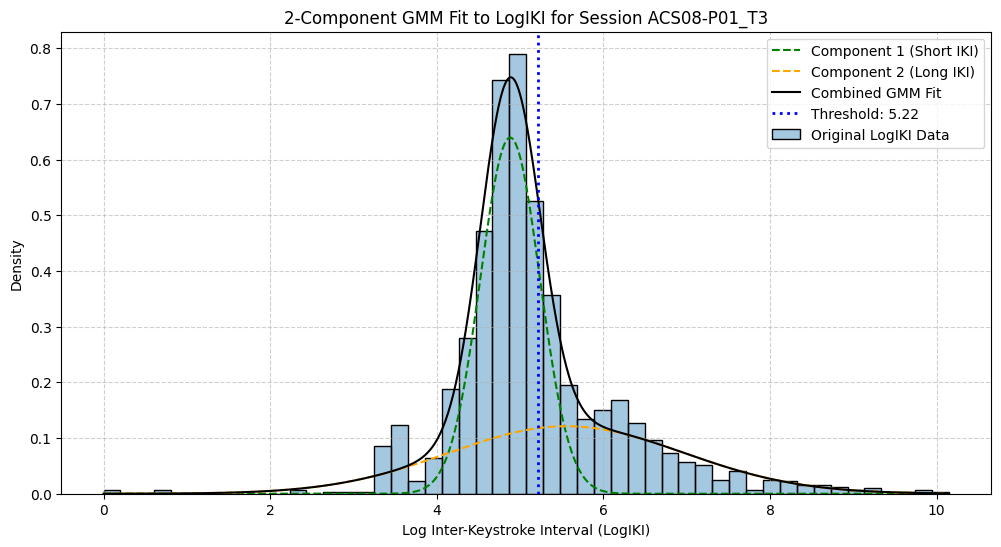

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
import pandas as pd
# Assuming KDdf_iki and session_data are defined from your initial setup
# And assuming the modified get_gmm_thresholds_logiki function is available

# 1. Prepare the data
# X will be the data used for fitting
X = session_data['LogIKI'].values.reshape(-1, 1)

# 2. Fit the GMM (using n_components=2 as in your previous use case)
n_components = 2
random_state = 42

gmm = GaussianMixture(n_components=n_components, random_state=random_state)
gmm.fit(X)

# Extract parameters and sort them by mean (from smallest to largest)
means = gmm.means_.flatten()
covariances = gmm.covariances_.flatten()
weights = gmm.weights_.flatten()
stds = np.sqrt(covariances)

# Sort by mean
order = np.argsort(means)
means, stds, weights = means[order], stds[order], weights[order]

# 3. Calculate the intersection threshold (You'll need the find_intersection function here)
def find_intersection(mean1, std1, mean2, std2):
    # This is the function from the previous response needed to calculate the threshold
    from scipy.optimize import brentq
    func = lambda x: norm.pdf(x, mean1, std1) - norm.pdf(x, mean2, std2)
    a = min(mean1 - 3*std1, mean2 - 3*std2)
    b = max(mean1 + 3*std1, mean2 + 3*std2)
    if func(a) * func(b) > 0:
        return (mean1 + mean2) / 2
    try:
        return brentq(func, a, b)
    except ValueError:
        return (mean1 + mean2) / 2

# Only one threshold for n_components=2
threshold_auto_inter = find_intersection(means[0], stds[0], means[1], stds[1])


# 4. Plotting
plt.figure(figsize=(12, 6))

# Plot the original data histogram
sns.histplot(data=session_data, x='LogIKI', bins=50, stat='density', alpha=0.4, label='Original LogIKI Data')

# Plot the fitted Gaussian components
x_axis = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
colors = ['green', 'orange']
labels = ['Component 1 (Short IKI)', 'Component 2 (Long IKI)'] # Simplified labels for 2 components

# Iterate through the sorted components
for i in range(n_components):
    # multiply the PDF by its weight to scale it correctly
    pdf = norm.pdf(x_axis, means[i], stds[i]) * weights[i]
    plt.plot(x_axis, pdf, color=colors[i], linestyle='--', label=labels[i])

# Plot the combined GMM PDF
total_pdf = gmm.score_samples(x_axis)
plt.plot(x_axis, np.exp(total_pdf), color='black', label='Combined GMM Fit')

# Draw the threshold line
plt.axvline(threshold_auto_inter, color='blue', linestyle=':', linewidth=2, label=f'Threshold: {threshold_auto_inter:.2f}')

plt.title(f'2-Component GMM Fit to LogIKI for Session {session_id_to_plot}')
plt.xlabel('Log Inter-Keystroke Interval (LogIKI)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [28]:
import sys
import importlib
import numpy as np
import pandas as pd
import os.path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq
import warnings

# Suppress ConvergenceWarning from GMM
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

KDdf = KDdf_old.copy() 
KDdf = KDdf.sort_values(by=['StudySession', 'Time'])
KDdf['IKI'] = KDdf.groupby('StudySession')['Time'].diff()
KDdf_iki = KDdf.dropna(subset=['IKI']).copy()
KDdf_iki['LogIKI'] = np.log(KDdf_iki.IKI)

# Calculate LogPUB for all StudySessions ---
AUdf_logpub = AUdf_old.copy()
AUdf_logpub = AUdf_logpub.drop_duplicates(subset=['StudySession'])

# Calculate the LogPUB (using the logic PUB/3)
AUdf_logpub['PUB1'] = AUdf_logpub['PUB'] / 3
AUdf_logpub['LogPUB'] = np.log(AUdf_logpub.PUB1)
AUdf_logpub['KBI1'] = AUdf_logpub['KBI'] / 2
AUdf_logpub['LogKBI'] = np.log(AUdf_logpub.KBI1)
AUdf_logpub_final = AUdf_logpub[['StudySession', 'LogPUB','LogKBI']].copy()
print("LogPUB,LogKBI calculation complete for all sessions.")


#  Define GMM Threshold Function and Apply to all StudySessions ---

def find_intersection(mean1, std1, mean2, std2):
    """
    Find intersection between two Gaussian PDFs by solving the quadratic equation 
    or using brentq if the quadratic formula is not used directly.
    
    If the GMM is unweighted, the threshold is calculated by:
    a * x^2 + b * x + c = 0
    where a = 1/(2*std1^2) - 1/(2*std2^2)
          b = mu2/(std2^2) - mu1/(std1^2)
          c = mu1^2/(2*std1^2) - mu2^2/(2*std2^2) - log(std2/std1)
    """
    from scipy.optimize import brentq
    
    # Define the difference function for root finding
    func = lambda x: norm.pdf(x, mean1, std1) - norm.pdf(x, mean2, std2)
    
    # Define search interval based on 3 standard deviations around each mean
    a = min(mean1 - 3 * std1, mean2 - 3 * std2)
    b = max(mean1 + 3 * std1, mean2 + 3 * std2)
    
    # Check for sign change and adjust bounds if possible (brentq requirement)
    if func(a) * func(b) > 0:
        # If no sign change in a reasonable range, extend the range slightly
        # Or simply return the midpoint as a fallback if intersection is too far/non-existent
        a_new = min(mean1, mean2) - 5 * max(std1, std2)
        b_new = max(mean1, mean2) + 5 * max(std1, std2)
        
        if func(a_new) * func(b_new) < 0:
            a, b = a_new, b_new
        else:
            # Still no sign change, intersection may be too far or non-existent
            # Return the midpoint as a simple classification boundary fallback
            return (mean1 + mean2) / 2

    try:
        # Use brentq to find the root within the interval [a, b]
        return brentq(func, a, b)
    except ValueError:
        # Catch any unexpected errors (e.g., failed convergence) -> fallback
        return (mean1 + mean2) / 2


def get_gmm_threshold_by_session(log_iki_data_series, n_components=2, random_state=42):
    """
    Fit GMM to LogIKI data for a single session and calculate threshold.
    Returns: float (threshold) or np.nan if fitting fails or n_components < 2.
    """
    
    if len(log_iki_data_series) < n_components:
        return np.nan
        
    X = log_iki_data_series.values.reshape(-1, 1)
    
    try:
        gmm = GaussianMixture(n_components=n_components, random_state=random_state)
        gmm.fit(X)
        
        means = gmm.means_.flatten()
        covariances = gmm.covariances_.flatten()
        stds = np.sqrt(covariances)

        # Sort components by mean (from smallest to largest)
        order = np.argsort(means)
        means, stds = means[order], stds[order]

        # Calculate the intersection threshold between the first two components
        threshold_inter = find_intersection(means[0], stds[0], means[1], stds[1])
        
        return threshold_inter
        
    except Exception:
        # Return NaN if GMM fitting or parameter extraction fails
        return np.nan


# Group the KDdf_iki by StudySession and apply the GMM threshold calculation
gmm_thresholds = KDdf_iki.groupby('StudySession')['LogIKI'].apply(get_gmm_threshold_by_session).reset_index(name='GMM_Threshold_LogIKI')

print("GMM Threshold calculation complete for all sessions.")

# --- Create the final summary DataFrame ---

# Merge the LogPUB and GMM Threshold DataFrames
summary_df = pd.merge(AUdf_logpub_final, gmm_thresholds, on='StudySession', how='inner')

print("\nFinal Summary DataFrame (first 5 rows):")
print(summary_df.head())

LogPUB,LogKBI calculation complete for all sessions.
GMM Threshold calculation complete for all sessions.

Final Summary DataFrame (first 5 rows):
   StudySession    LogPUB    LogKBI  GMM_Threshold_LogIKI
0  ACS08-P03_T1  5.505332  5.123964              6.938764
1  ACS08-P08_T1  5.247024  5.087596              5.650591
2  ACS08-P10_T1  5.407172  4.976734              5.440663
3  ACS08-P07_T3  5.497168  4.990433              5.269511
4  ACS08-P14_T3  6.073045  5.159055              5.631015


In [29]:
pd.set_option('display.max_rows', None)
summary_df

,StudySession,LogPUB,LogKBI,GMM_Threshold_LogIKI
0,ACS08-P03_T1,5.505332,5.123964,6.938764
1,ACS08-P08_T1,5.247024,5.087596,5.650591
2,ACS08-P10_T1,5.407172,4.976734,5.440663
3,ACS08-P07_T3,5.497168,4.990433,5.269511
4,ACS08-P14_T3,6.073045,5.159055,5.631015
5,ACS08-P04_T4,5.488938,4.912655,5.238673
6,ACS08-P16_T3,5.799093,5.030438,5.700340
7,ACS08-P09_T3,6.338594,5.081404,5.552467
8,ACS08-P01_T4,5.252273,4.890349,5.355125
9,ACS08-P17_T2,5.480639,5.017280,5.484919



Generating GMM and LogIKI/LogPUB plots for the first 10 sessions.


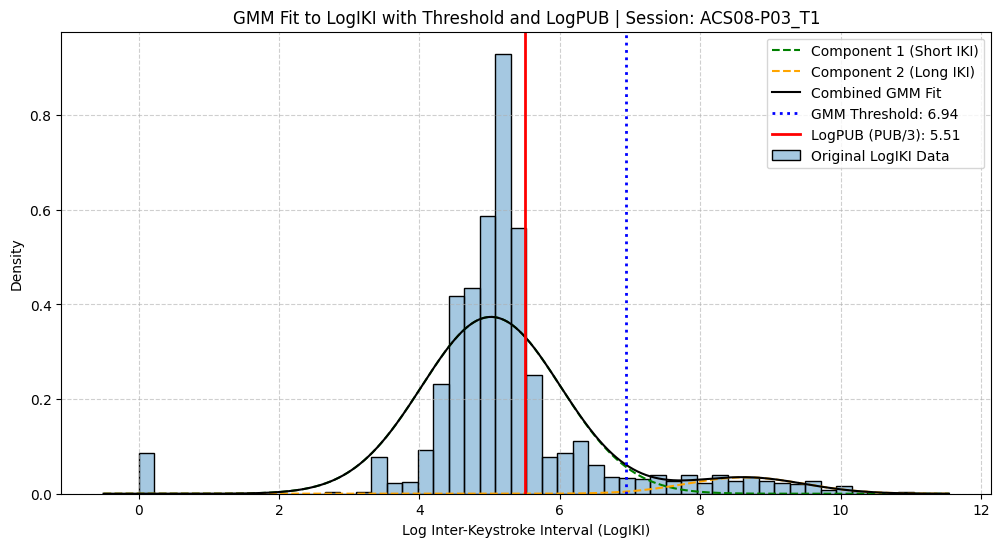

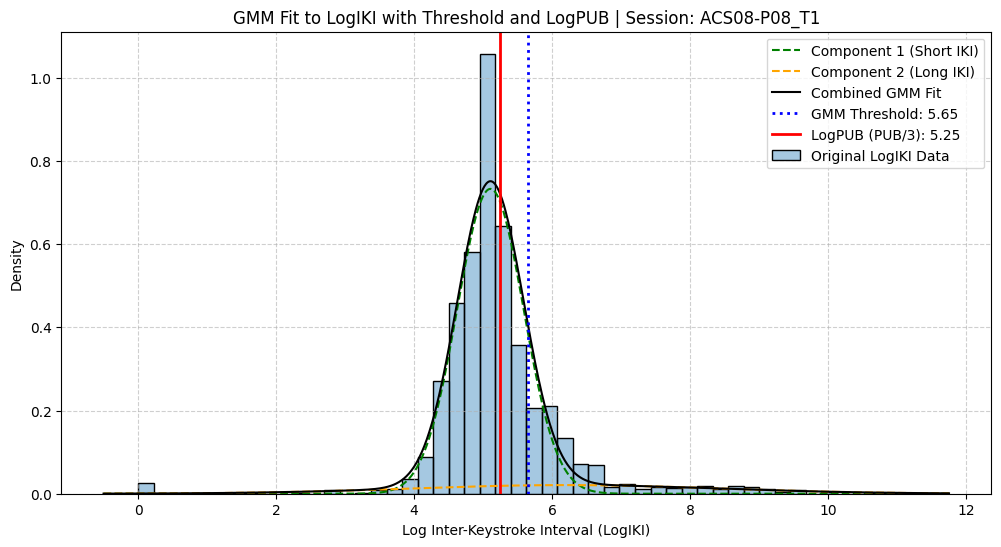

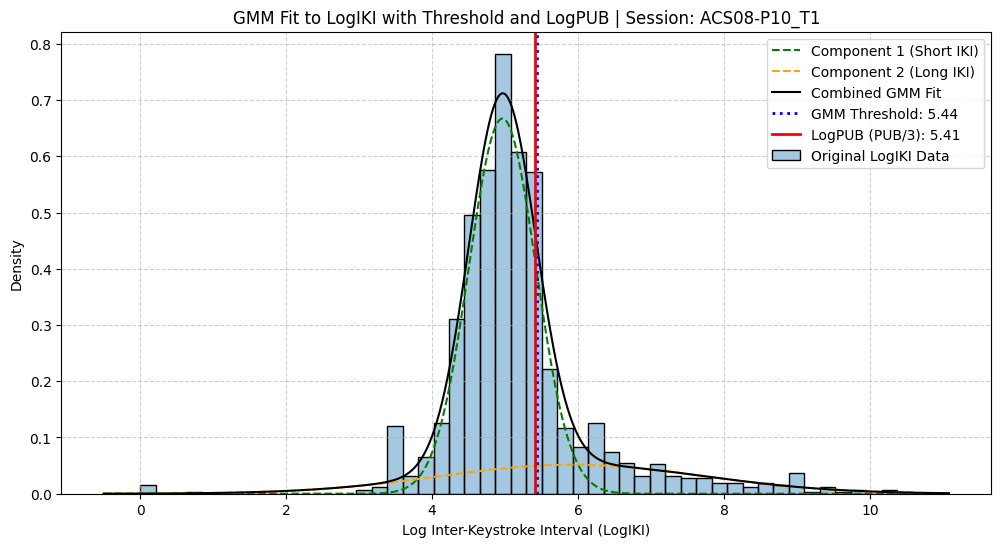

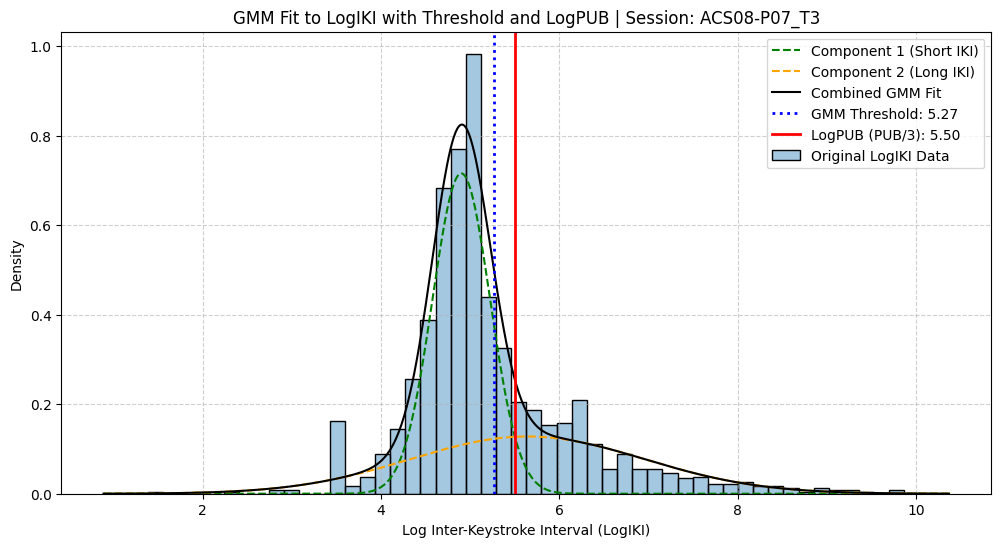

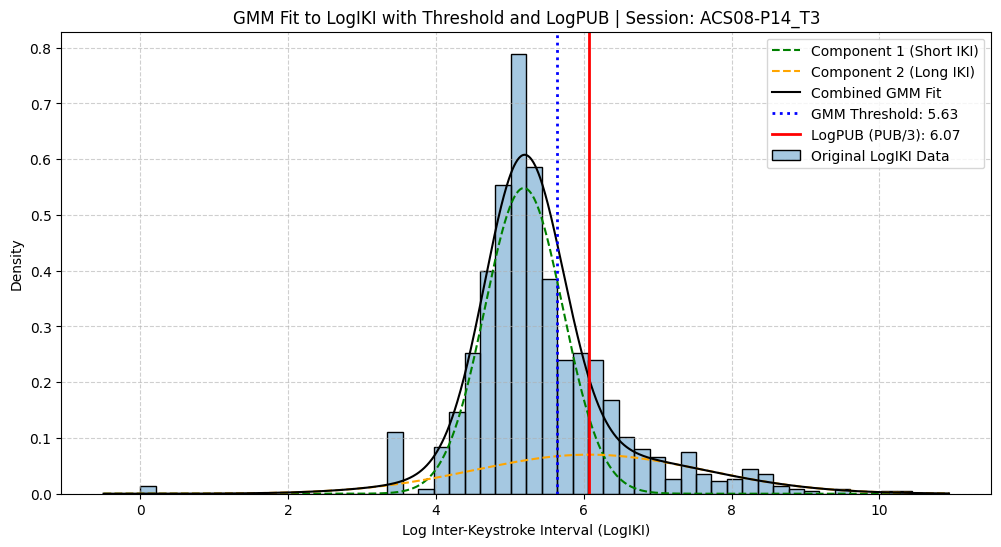

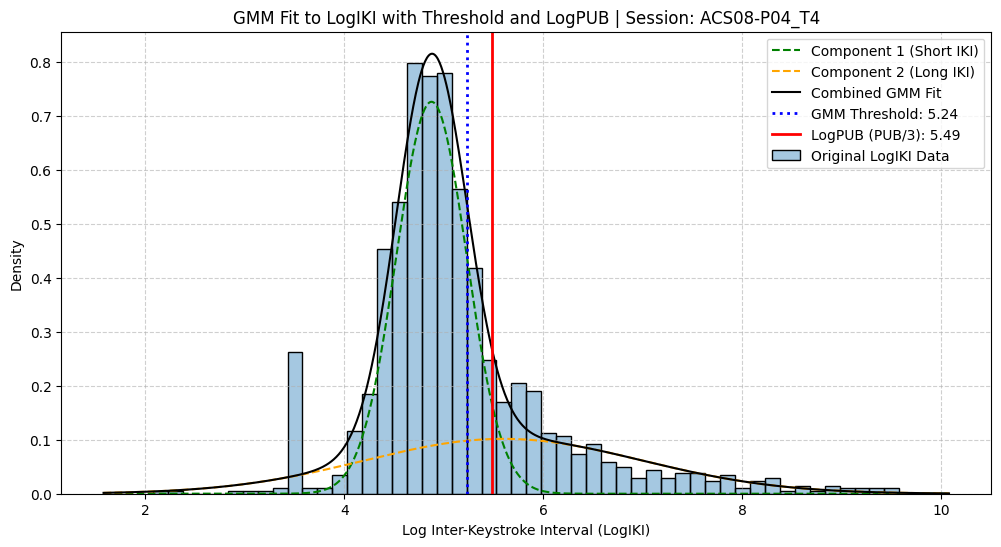

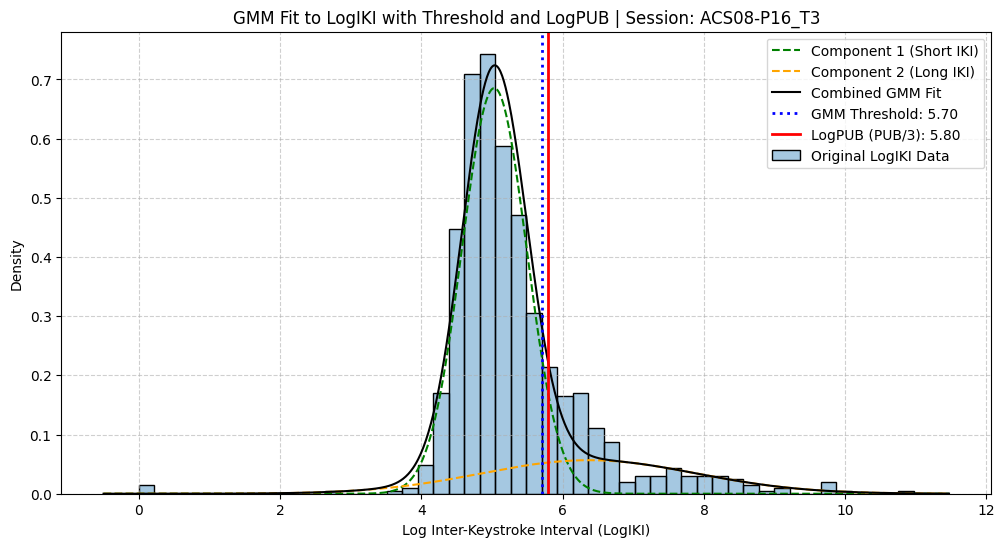

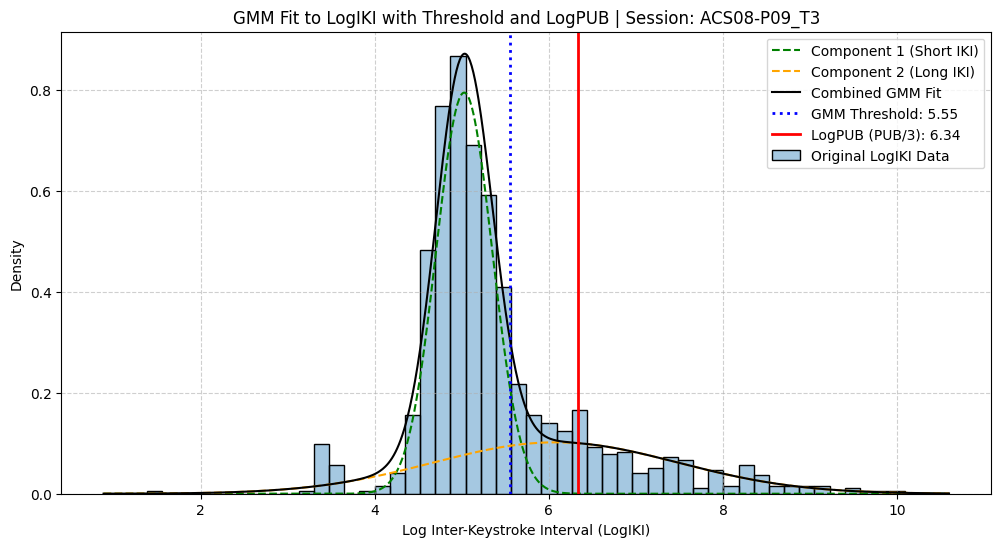

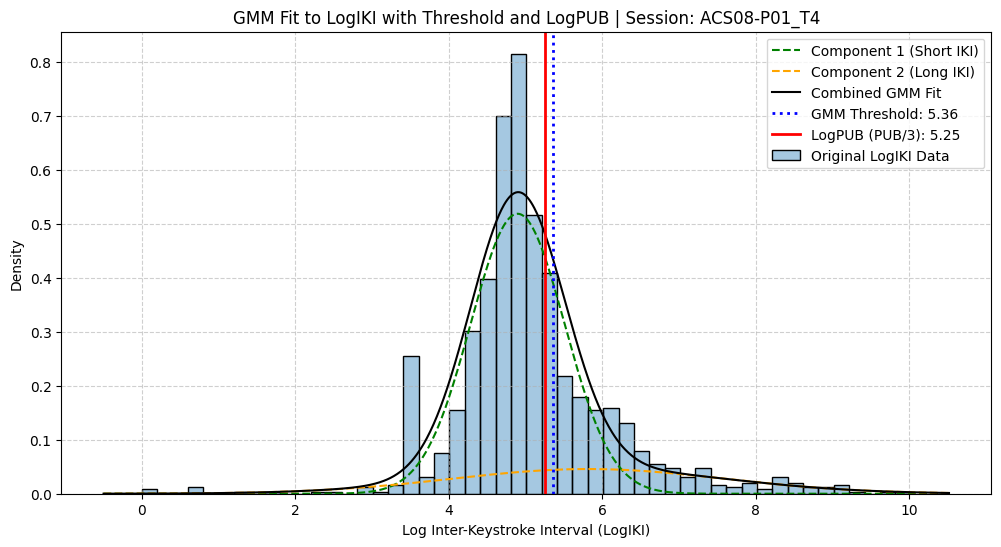

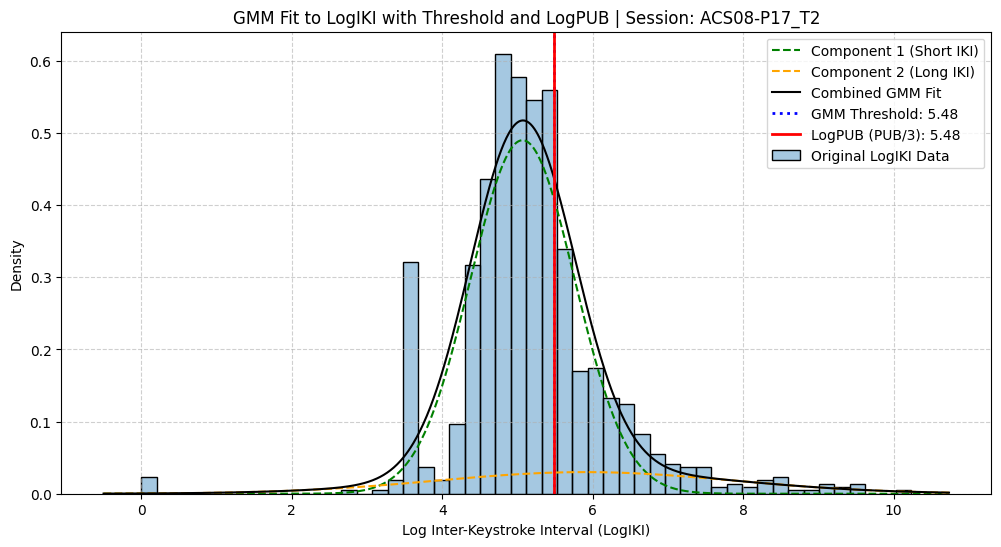

In [16]:
# ---  Plotting GMM and LogPUB for the first 10 StudySessions ---

# Get the first 10 unique StudySession IDs that had a successful GMM fit
sessions_to_plot = summary_df.dropna(subset=['GMM_Threshold_LogIKI'])['StudySession'].unique()[:10]

print(f"\nGenerating GMM and LogIKI/LogPUB plots for the first {len(sessions_to_plot)} sessions.")

for session_id in sessions_to_plot:
    
    # 1. Get data for the specific session
    session_data = KDdf_iki[KDdf_iki['StudySession'] == session_id]
    log_iki_data_series = session_data['LogIKI']
    threshold_auto_inter = summary_df[summary_df['StudySession'] == session_id]['GMM_Threshold_LogIKI'].iloc[0]
    log_pub_value = AUdf_logpub_final[AUdf_logpub_final['StudySession'] == session_id]['LogPUB'].iloc[0]
    
    if pd.isna(threshold_auto_inter):
        print(f"Skipping plot for session {session_id}: GMM threshold is NaN.")
        continue

    # 2. Fit the GMM again (to get the parameters for plotting)
    X = log_iki_data_series.values.reshape(-1, 1)
    n_components = 2
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(X)
    
    means = gmm.means_.flatten()
    covariances = gmm.covariances_.flatten()
    weights = gmm.weights_.flatten()
    stds = np.sqrt(covariances)
    
    order = np.argsort(means)
    means, stds, weights = means[order], stds[order], weights[order]

    # 3. Plotting
    plt.figure(figsize=(12, 6))

    # Plot the original data histogram
    sns.histplot(data=session_data, x='LogIKI', bins=50, stat='density', alpha=0.4, label='Original LogIKI Data')

    # X-axis for plotting PDFs
    x_axis = np.linspace(log_iki_data_series.min() - 0.5, log_iki_data_series.max() + 0.5, 1000).reshape(-1, 1)
    
    # Plot the fitted Gaussian components
    colors = ['green', 'orange']
    labels = ['Component 1 (Short IKI)', 'Component 2 (Long IKI)']
    
    for i in range(n_components):
        # Scale PDF by its weight
        pdf = norm.pdf(x_axis, means[i], stds[i]) * weights[i]
        plt.plot(x_axis, pdf, color=colors[i], linestyle='--', label=labels[i])

    # Plot the combined GMM PDF
    total_pdf = gmm.score_samples(x_axis)
    plt.plot(x_axis, np.exp(total_pdf), color='black', label='Combined GMM Fit')

    # Draw the GMM threshold line
    plt.axvline(threshold_auto_inter, color='blue', linestyle=':', linewidth=2, label=f'GMM Threshold: {threshold_auto_inter:.2f}')

    # Draw the LogPUB line
    plt.axvline(log_pub_value, color='red', linestyle='-', linewidth=2, label=f'LogPUB (PUB/3): {log_pub_value:.2f}')


    plt.title(f'GMM Fit to LogIKI with Threshold and LogPUB | Session: {session_id}')
    plt.xlabel('Log Inter-Keystroke Interval (LogIKI)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

- Mean Absolute Difference (MAD): on average, how far apart the two log values are, regardless of which one is larger.
- Mean Difference (MD): This value indicates the systematic bias. If it's close to zero, there is no consistent tendency for one metric to be higher than the other. If it's a large positive value, the GMM_Threshold_LogIKI is typically higher than LogPUB.
- Standard Deviation of the Difference (SDD): This value measures the consistency of the difference. A small standard deviation suggests the two metrics maintain a relatively stable distance from one another across all sessions, while a large one indicates the difference varies significantly between sessions.



In [26]:

comparison_df = summary_df.dropna(subset=['GMM_Threshold_LogIKI', 'LogPUB']).copy()

# Calculate the difference between the two metrics for each session
comparison_df['Difference'] = comparison_df['GMM_Threshold_LogIKI'] - comparison_df['LogPUB']

# Calculate the Mean Absolute Difference (MAD)
mean_absolute_difference = comparison_df['Difference'].abs().mean()

# Calculate the Mean Difference (MD)
mean_difference = comparison_df['Difference'].mean()

# Calculate the Standard Deviation of the Difference (SDD)
std_dev_difference = comparison_df['Difference'].std()

# Calculate the total number of sessions compared
num_sessions_compared = len(comparison_df)

print(f"Comparison of LogPUB vs. GMM_Threshold_LogIKI (N={num_sessions_compared} sessions):")
print("\n")
print(f"1. Mean Absolute Difference (MAD): {mean_absolute_difference:.4f}")
print(f"2. Mean Difference (MD): {mean_difference:.4f}")
print(f"3. Standard Deviation of the Difference (SDD): {std_dev_difference:.4f}")


Comparison of LogPUB vs. GMM_Threshold_LogIKI (N=490 sessions):


1. Mean Absolute Difference (MAD): 0.5403
2. Mean Difference (MD): -0.3802
3. Standard Deviation of the Difference (SDD): 1.1953


- On average, the GMM_Threshold_LogIKI is 0.3802 units lower than the LogPUB value (GMM_Threshold_LogIKI<LogPUB) across the 490 sessions.
- In some sessions, GMM_Threshold might be much lower, and in others, it could even be higher than LogPUB.